DATA-110

 PROJECT CODE

JEEVAN C

FALL A 2025

1. Introduction to the Notebook

This notebook presents the exploratory data analysis and preliminary machine learning preparation for detecting fraudulent blockchain transactions using machine learning techniques. Blockchain technology is widely used for digital financial transactions due to its decentralized and transparent nature. However, despite its security advantages, blockchain networks are still vulnerable to fraudulent activities such as illegal transactions, money laundering, and financial manipulation.

The primary objective of this analysis is to explore blockchain transaction data and identify patterns that distinguish fraudulent transactions from legitimate ones. Machine learning techniques can assist in analyzing large volumes of transaction data and detecting suspicious behavior that may not be easily visible through manual analysis.

The dataset used in this project contains blockchain transaction features along with labels indicating whether a transaction is legitimate or illicit. Before applying machine learning algorithms, it is essential to perform exploratory data analysis to understand the dataset structure, identify missing values, detect anomalies, and explore relationships between variables.

Through data visualization and statistical analysis, the notebook aims to gain insights into transaction behavior, detect patterns associated with fraudulent activities, and prepare the dataset for machine learning model development.

In [51]:
#===========================================================================================================================
#===========================================================================================================================

2. Importing Libraries

Explanation

The first step in any data analysis project is importing the necessary libraries that provide tools for data manipulation, visualization, and machine learning. In this project, several Python libraries are used to perform different tasks.

Pandas is used for data loading, manipulation, and analysis. It provides powerful data structures such as DataFrames that allow efficient handling of structured datasets.

NumPy is used for numerical computations and handling arrays. Many machine learning operations rely on efficient numerical processing provided by NumPy.

Matplotlib and Seaborn are used for data visualization. These libraries allow the creation of graphs, charts, and plots that help visualize patterns and relationships in the data.

Scikit-learn is a popular machine learning library that provides algorithms for classification, regression, clustering, and model evaluation. In this project, it will be used for implementing machine learning models to detect fraudulent transactions.

Importing these libraries at the beginning ensures that all required functions and tools are available throughout the notebook.

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

3. Loading the Dataset

Explanation

The next step involves loading the blockchain transaction dataset into the notebook environment. The dataset consists of multiple files containing transaction features, transaction labels, and network relationships between transactions.

The features dataset contains various attributes that describe transaction behavior within the blockchain network. These features represent characteristics such as transaction structure, network properties, and statistical indicators derived from transaction history.

The classes dataset contains labels indicating whether each transaction is legitimate or illicit. These labels are used as the target variable for machine learning classification.

The edges dataset represents the connections between transactions in the blockchain network, showing how transactions are linked to each other. Although this dataset can be used for network analysis, the primary focus of this project is on transaction features and classification.

Loading the dataset allows the analysis to begin by inspecting its structure and understanding the available variables.

In [53]:
features = pd.read_csv("elliptic_txs_features.csv", header=None)
classes = pd.read_csv("elliptic_txs_classes.csv")
edges = pd.read_csv("elliptic_txs_edgelist.csv")

4. Data Preprocessing and Merging

Explanation

After loading the dataset, it is necessary to preprocess the data to ensure it is properly structured for analysis. In this dataset, the transaction identifier column in the features file does not have a proper column name. Therefore, the first step involves renaming the column to “txId” so that it matches the identifier used in the classes dataset.

Once the column names are aligned, the features dataset is merged with the classes dataset using the transaction identifier as the common key. This process combines transaction attributes with their corresponding class labels, creating a single dataset that contains both features and target variables.

Data preprocessing also involves removing transactions labeled as “unknown.” These entries do not have clear labels indicating whether they are fraudulent or legitimate, which makes them unsuitable for supervised machine learning models. By filtering out these entries and converting the class variable into a numeric format, the dataset becomes suitable for further analysis and modeling.

Proper preprocessing ensures that the dataset is clean, structured, and ready for exploratory data analysis.

In [54]:
features.rename(columns={0: "txId"}, inplace=True)

In [55]:
print(features.columns)
print(classes.columns)

Index(['txId',      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
          157,    158,    159,    160,    161,    162,    163,    164,    165,
          166],
      dtype='object', length=167)
Index(['txId', 'class'], dtype='object')


In [56]:
features = features.rename(columns={0: "txId"})

In [57]:
print(features.columns)

Index(['txId',      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
          157,    158,    159,    160,    161,    162,    163,    164,    165,
          166],
      dtype='object', length=167)


In [58]:
data = pd.merge(features, classes, on="txId")
data.head()

,txId,1,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


In [59]:
data = data[data['class'] != 'unknown']
data['class'] = data['class'].astype(int)

5. Dataset Inspection

Explanation

Before performing visual analysis, it is important to inspect the dataset to understand its overall structure and characteristics. Dataset inspection involves examining the number of observations, the number of features, and the data types associated with each variable.

The head function allows viewing the first few rows of the dataset to verify that the data has been loaded correctly and that the merging process was successful.

The info function provides detailed information about the dataset, including the number of entries, column names, and data types. This helps identify whether any variables need type conversion or cleaning.

The describe function generates descriptive statistics such as mean, standard deviation, minimum, and maximum values for numerical variables. These statistics provide an initial overview of the distribution and variability of the dataset.

Understanding the dataset structure helps researchers identify potential issues such as missing values, inconsistent data types, or unusual distributions that may require further preprocessing.

In [60]:
data.head()
data.shape
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 46564 entries, 3 to 203766
Columns: 168 entries, txId to class
dtypes: float64(165), int64(3)
memory usage: 60.0 MB


,txId,1,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,class
count,4.656400e+04,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,...,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000
mean,1.745082e+08,24.599046,-0.052645,0.159103,0.148974,0.172216,0.028651,0.184429,-0.015381,-0.077488,...,-0.021395,0.088977,0.088828,-0.010401,0.057301,0.076348,0.045520,-0.037397,-0.037899,1.902392
std,1.111707e+08,15.158091,0.702554,1.544040,1.063158,1.600931,1.729706,1.589399,0.577378,0.588778,...,0.956718,0.978313,0.979057,0.511929,1.729502,1.764513,1.065455,0.998764,0.998087,0.296787
min,2.534000e+03,1.000000,-0.172982,-0.210553,-1.756361,-0.121970,-0.063725,-0.113002,-0.061584,-0.163646,...,-0.626229,-0.979074,-0.978556,-0.216057,-0.125939,-0.131155,-0.269818,-1.760926,-1.760984,1.000000
25%,8.656573e+07,10.000000,-0.172683,-0.162140,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.163614,...,-0.588384,-0.979074,-0.978556,-0.098889,-0.087490,-0.131155,-0.140597,-0.120613,-0.119792,2.000000
50%,1.637240e+08,24.000000,-0.170652,-0.113851,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,-0.163383,...,-0.443313,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,2.000000
75%,2.463727e+08,39.000000,-0.141446,0.016948,1.018602,0.028105,-0.043875,-0.029140,-0.061584,-0.158465,...,0.105434,1.461330,1.461369,0.018279,-0.068266,-0.084674,-0.083166,0.139080,0.110398,2.000000
max,4.031232e+08,49.000000,39.786756,73.595052,2.683580,49.027598,260.090707,54.565178,44.365651,40.721063,...,7.888811,1.461330,1.461369,58.485180,251.849028,238.783493,86.778382,1.519700,1.521399,2.000000


In [74]:
print(data.columns)

Index([ 'txId',       1,       2,       3,       4,       5,       6,       7,
             8,       9,
       ...
           158,     159,     160,     161,     162,     163,     164,     165,
           166, 'class'],
      dtype='object', length=168)


In [61]:
print(data.shape)

(46564, 168)


In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
features.rename(columns={0: "txId"}, inplace=True)
data = features.merge(classes, on="txId")
data.head()

,txId,1,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


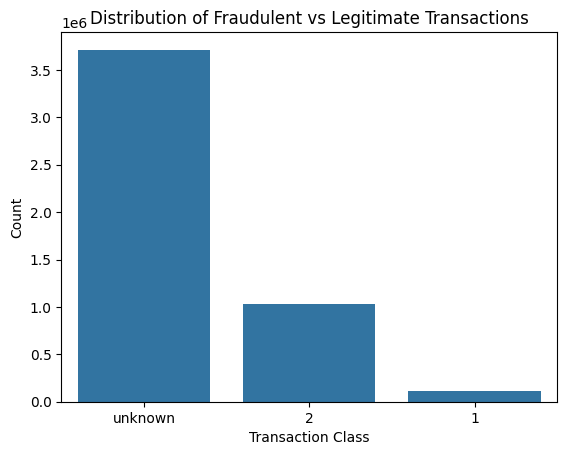

In [65]:
sns.countplot(x='class', data=data)
plt.title("Distribution of Fraudulent vs Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Count")
plt.show()

6.Count Plot with unknown

Explanation

The Count Plot with unknown is illustrates the distribution of transaction classes in the dataset. The dataset contains three categories: unknown transactions, fraudulent transactions (Class 1), and legitimate transactions (Class 2). A large proportion of the transactions fall under the unknown category, indicating that many transactions do not have confirmed labels. Among the labeled transactions, legitimate transactions are significantly higher than fraudulent transactions, which shows a clear class imbalance. This type of imbalance is common in blockchain and financial transaction datasets where fraudulent activities represent only a small fraction of total transactions. The presence of many unknown transactions highlights the difficulty of accurately labeling blockchain data. This visualization helps in understanding the overall composition of the dataset and emphasizes the importance of preprocessing steps, such as filtering unknown transactions, before applying machine learning models for fraud detection.

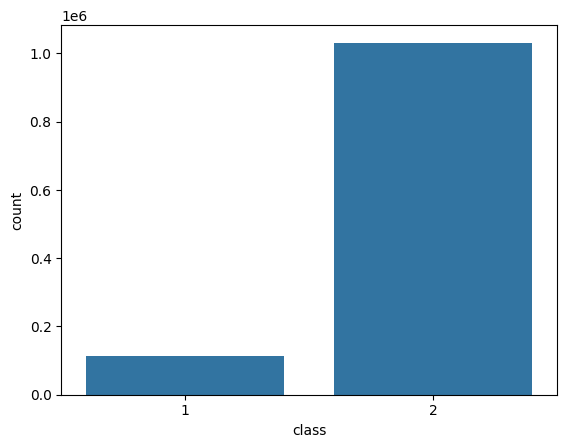

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='class', data=data)
plt.show()

6. Count Plot (Fraud vs Legitimate Transactions)

Explanation

The count plot visualizes the distribution of transaction classes in the dataset. Specifically, it shows how many transactions are labeled as legitimate and how many are labeled as fraudulent.

Fraud detection datasets often exhibit a class imbalance where legitimate transactions greatly outnumber fraudulent ones. This imbalance can make it difficult for machine learning models to correctly identify rare fraudulent cases. If a model simply predicts all transactions as legitimate, it may achieve high accuracy while still failing to detect fraud.

By visualizing the distribution of transaction classes, researchers can better understand the scale of the imbalance problem and consider appropriate strategies such as resampling techniques, anomaly detection methods, or specialized evaluation metrics that emphasize fraud detection performance.

This visualization is therefore an essential step in understanding the dataset and preparing for machine learning modeling.

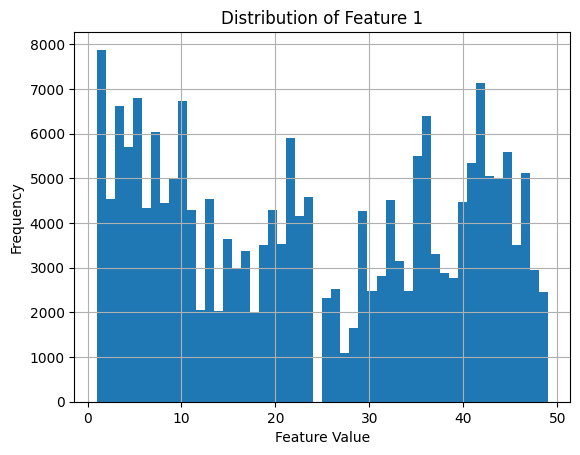

In [66]:

data[1].hist(bins=50)
plt.title("Distribution of Feature 1")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.show()


7. Histogram (Feature Distribution)

Explanation

A histogram is used to analyze the distribution of numerical values for a specific feature within the dataset. It divides the data into intervals and shows how frequently values fall within each interval.

In blockchain transaction analysis, feature distributions may reveal important patterns about transaction behavior. For example, some features may follow a normal distribution, while others may be heavily skewed or contain extreme values.

Understanding the distribution of features helps determine whether transformations such as normalization or scaling are required before training machine learning models. Features with very large ranges or skewed distributions may negatively affect model performance if not properly handled.

Therefore, histograms provide valuable insight into the statistical properties of the dataset.

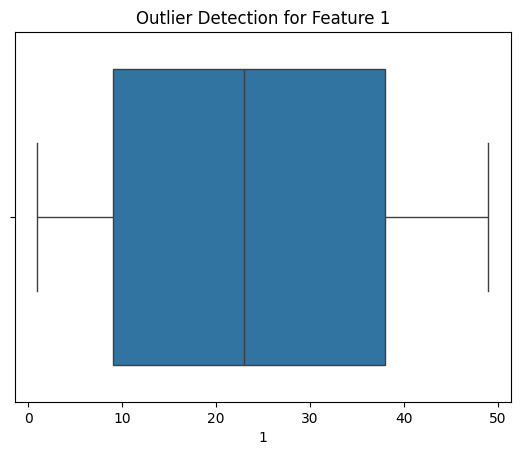

In [67]:
sns.boxplot(x=data[1])
plt.title("Outlier Detection for Feature 1")
plt.show()

8. Box Plot (Outlier Detection)

Explanation

The box plot is used to detect outliers and visualize the spread of feature values. It displays the median, quartiles, and extreme values within the dataset.

Outliers are data points that significantly differ from the majority of observations. In financial transaction datasets, outliers may represent unusual or suspicious activities. In some cases, these anomalies could be indicators of fraudulent behavior.

The box plot helps identify such extreme values and allows researchers to decide whether they should be removed, transformed, or further investigated.

Understanding outliers is important because they can affect statistical analysis and machine learning models. Properly handling outliers ensures more reliable and accurate predictive performance.

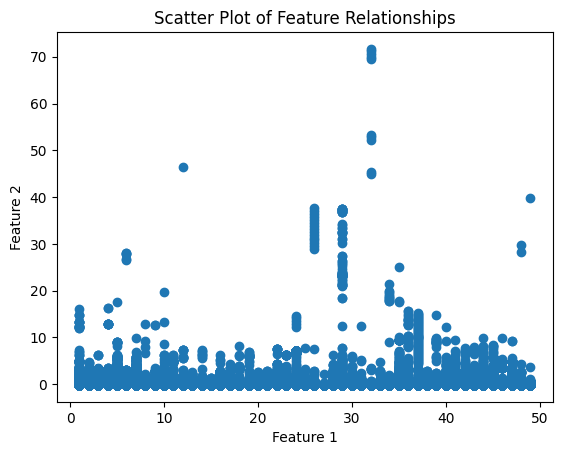

In [68]:
plt.scatter(data[1], data[2])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter Plot of Feature Relationships")
plt.show()

9. Scatter Plot (Feature Relationship)

Explanation

The scatter plot is used to analyze the relationship between two different features in the dataset. Each point in the plot represents a transaction, with its position determined by the values of the two selected features.

Scatter plots help identify correlations, clusters, or patterns between variables. In fraud detection studies, certain combinations of features may distinguish fraudulent transactions from legitimate ones.

By visualizing relationships between variables, researchers can gain insight into how different transaction attributes interact. This information can guide feature selection and help determine which variables are most relevant for machine learning models.

Scatter plots are therefore an important tool for exploring complex relationships within the dataset.

In [69]:
data = data[data['class'] != 'unknown']
data['class'] = data['class'].astype(int)

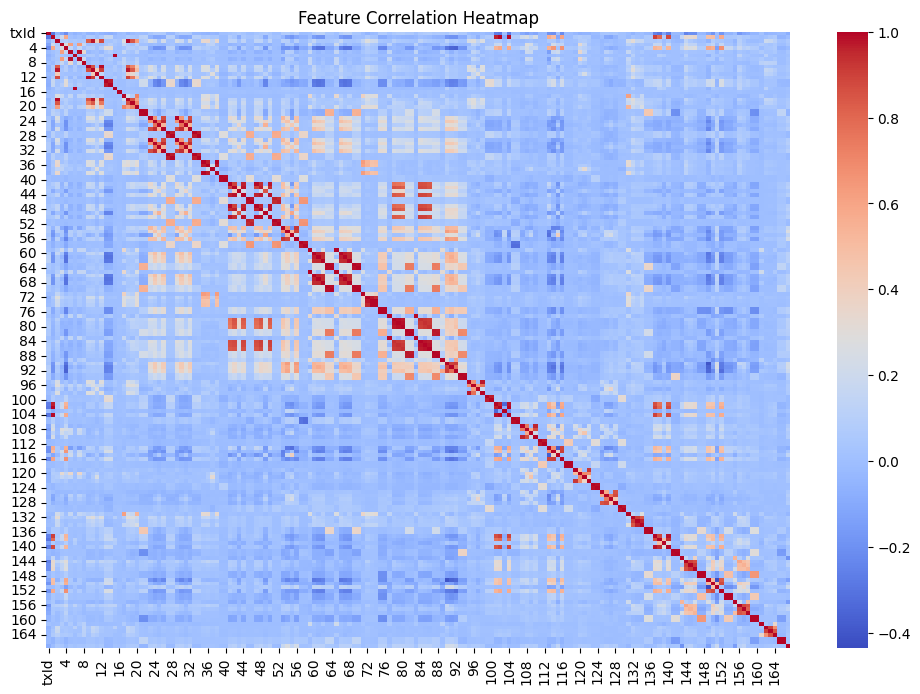

In [70]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

10. Correlation Heatmap

Explanation

The correlation heatmap provides a comprehensive visualization of relationships between all numerical features in the dataset. Each cell in the heatmap represents the correlation coefficient between two variables.

Correlation values range from -1 to +1. A value close to +1 indicates a strong positive relationship, meaning that both variables increase together. A value close to -1 indicates a strong negative relationship, meaning that one variable decreases as the other increases. Values near zero indicate little or no relationship between variables.

Understanding correlations is important for feature selection in machine learning. Highly correlated variables may provide redundant information, while independent variables may contribute unique predictive value.

By examining the correlation heatmap, researchers can identify patterns and relationships that may influence the performance of fraud detection models.

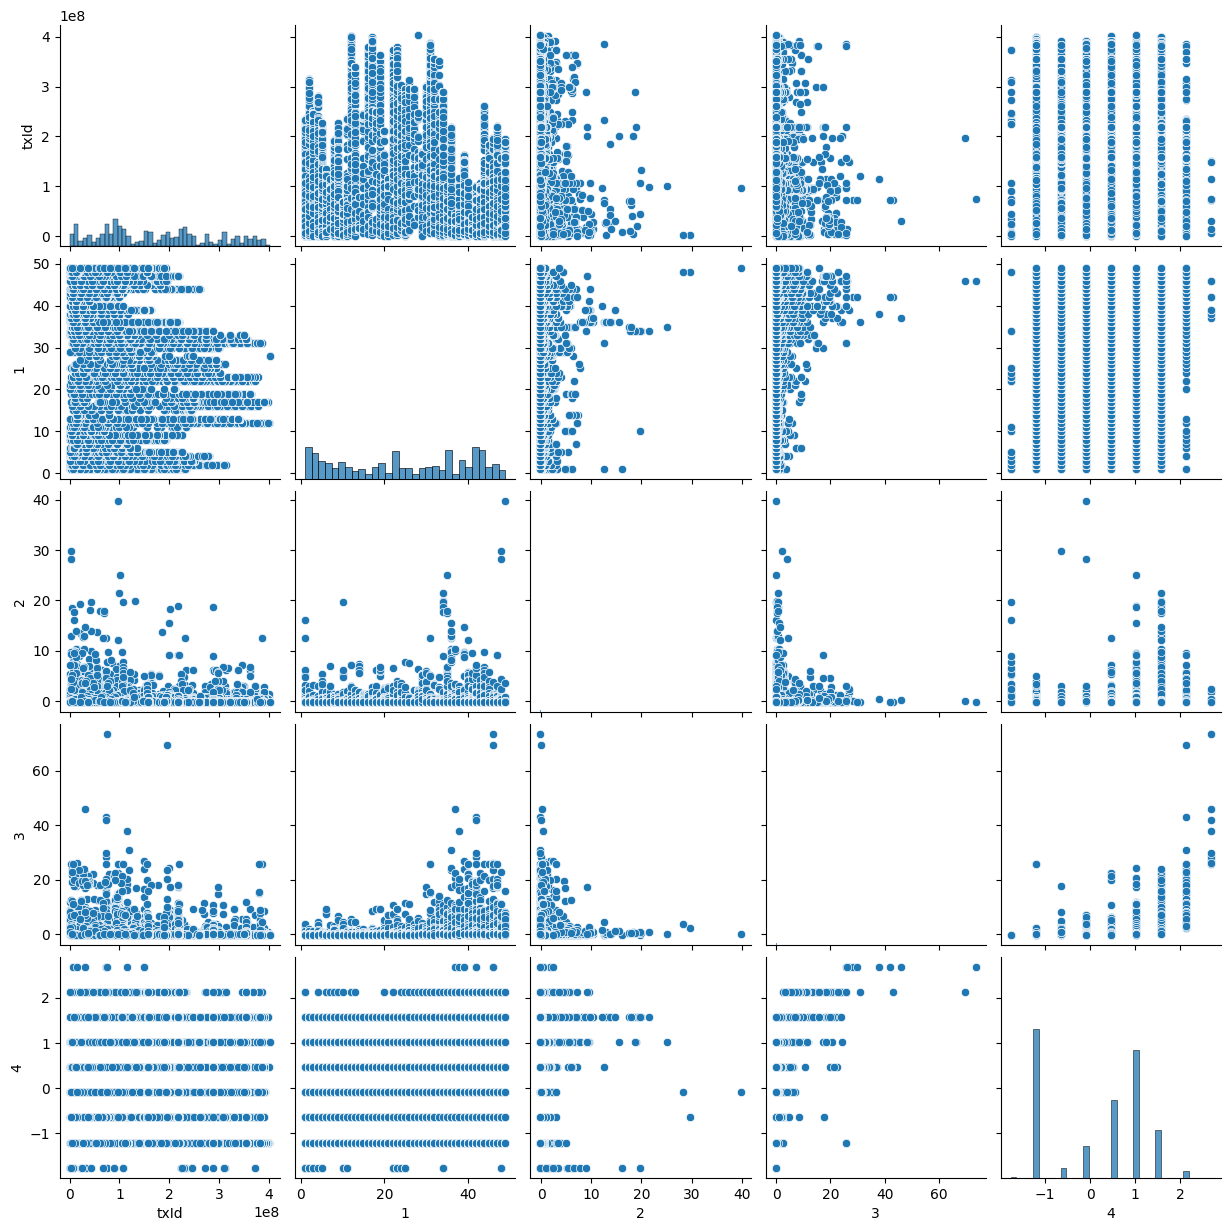

In [71]:
sns.pairplot(data.iloc[:,0:5])
plt.show()

11.pairplot Explanation

Explanation

The pair plot visualizes pairwise relationships between multiple features simultaneously. It displays scatter plots for each pair of variables along with histograms or density plots for individual features. This type of visualization helps researchers understand how different variables interact and whether certain combinations of features create clusters or patterns. In fraud detection applications, pair plots can reveal whether fraudulent transactions form distinct clusters compared to legitimate transactions. Such insights can be extremely useful when selecting features and designing machine learning models.

In [72]:
import os
os.listdir()

['.config',
 'elliptic_txs_edgelist.csv',
 'elliptic_txs_classes.csv',
 '.ipynb_checkpoints',
 'elliptic_txs_features.csv']

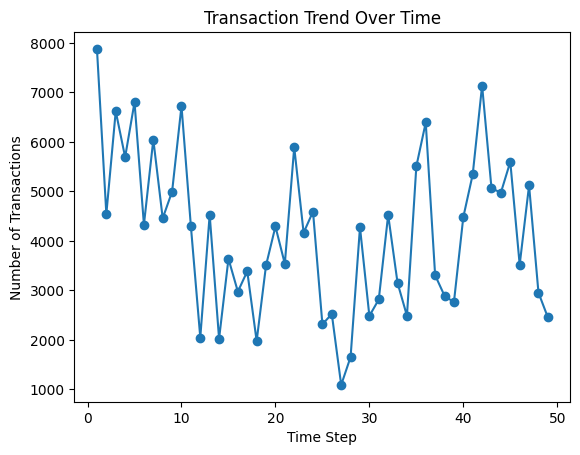

In [75]:
import pandas as pd
import matplotlib.pyplot as plt


features = pd.read_csv("elliptic_txs_features.csv", header=None)


features.rename(columns={0: "txId", 1: "time_step"}, inplace=True)


features.groupby("time_step").size().plot(kind="line", marker="o")

plt.title("Transaction Trend Over Time")
plt.xlabel("Time Step")
plt.ylabel("Number of Transactions")

plt.show()

12.Line Graph Explanation

Explanation

The line graph illustrates the trend of transaction counts across different classes in the dataset. Trend analysis helps in understanding how transaction behaviors vary between legitimate and fraudulent categories. By observing these patterns, it becomes easier to identify irregular activities that may indicate potential fraud. In blockchain networks, fraudulent transactions often occur in bursts or follow certain identifiable patterns over time. Visualizing transaction trends therefore provides valuable insights into how transaction behavior changes within the network. This analysis helps researchers and analysts better understand the distribution and dynamics of fraudulent activities in the dataset.

13. Overall Conclusion of the Notebook

The exploratory data analysis conducted in this notebook provides a comprehensive understanding of the blockchain transaction dataset. Through dataset inspection, statistical analysis, and data visualization, several important insights have been obtained regarding the distribution and relationships of transaction features.

The analysis reveals the presence of class imbalance between legitimate and fraudulent transactions, which is a common challenge in fraud detection problems. Additionally, visualization techniques such as histograms, box plots, scatter plots, and correlation heatmaps help identify patterns, outliers, and relationships between variables.

These insights are essential for preparing the dataset for machine learning modeling. Understanding the characteristics of the data allows researchers to select appropriate algorithms, apply necessary preprocessing techniques, and design effective models for detecting fraudulent blockchain transactions.

The results of this exploratory analysis will guide the next phase of the project, which involves implementing machine learning algorithms to classify transactions and evaluate the performance of fraud detection models.